In [127]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [128]:
import os

import pandas as pd
from pathlib import Path

from PIL import Image
import torch

from benchmark.metadata import *

import warnings
warnings.filterwarnings("ignore")

In [129]:
DATA_DIR = Path.cwd().parent.resolve() / "data"
metadata_dir = DATA_DIR / "GF1_B02_B03_B04_B08_Mask"
metadata_path = metadata_dir / "metadata.csv"

In [130]:
df = pd.read_csv(metadata_path)
df.head()

,filename,location,datetime,path
0,GF1_WFV1_E102.0_N28.0_20140302_L2A0000280476,E102.0-N28.0,2014/3/2,C:\Users\gaoha\PycharmProjects\PythonProject\d...
1,GF1_WFV1_E104.1_S0.6_20151012_L2A0001096133,E104.1-S0.6,2015/10/12,C:\Users\gaoha\PycharmProjects\PythonProject\d...
2,GF1_WFV1_E104.3_N12.9_20140522_L2A0000356326,E104.3-N12.9,2014/5/22,C:\Users\gaoha\PycharmProjects\PythonProject\d...
3,GF1_WFV1_E104.8_N51.3_20150617_L2A0000979951,E104.8-N51.3,2015/6/17,C:\Users\gaoha\PycharmProjects\PythonProject\d...
4,GF1_WFV1_E114.4_N38.0_20130505_L2A0000029007,E114.4-N38.0,2013/5/5,C:\Users\gaoha\PycharmProjects\PythonProject\d...


In [131]:
metadata = list(metadata_dir.glob("*.tif"))
metadata

[PosixPath('/Users/hangzegao/PycharmProjects/cloud/data/GF1_B02_B03_B04_B08_Mask/GF1_WFV4_W155.2_N20.2_20160721_L2A0001718813.tif'),
 PosixPath('/Users/hangzegao/PycharmProjects/cloud/data/GF1_B02_B03_B04_B08_Mask/GF1_WFV4_E121.8_N18.5_20130508_L2A0000017773.tif'),
 PosixPath('/Users/hangzegao/PycharmProjects/cloud/data/GF1_B02_B03_B04_B08_Mask/GF1_WFV4_W152.9_N21.9_20160806_L2A0001748198.tif'),
 PosixPath('/Users/hangzegao/PycharmProjects/cloud/data/GF1_B02_B03_B04_B08_Mask/GF1_WFV4_E89.3_N43.4_20130714_L2A0000063081.tif'),
 PosixPath('/Users/hangzegao/PycharmProjects/cloud/data/GF1_B02_B03_B04_B08_Mask/GF1_WFV3_E128.2_N58.6_20130517_L2A0000022013.tif'),
 PosixPath('/Users/hangzegao/PycharmProjects/cloud/data/GF1_B02_B03_B04_B08_Mask/GF1_WFV1_E68.0_N57.9_20130705_L2A0000356197.tif'),
 PosixPath('/Users/hangzegao/PycharmProjects/cloud/data/GF1_B02_B03_B04_B08_Mask/GF1_WFV2_E45.2_N32.6_20131130_L2A0000123045.tif')]

In [132]:
def update_path(row):
    file_suffix = ".tif"
    filename = row["filename"] + file_suffix
    path = os.path.join(metadata_dir, filename)
    return path

df["path"] = df.apply(update_path, axis=1)
df = df[df["path"].apply(os.path.exists)]
df.head(100)

,filename,location,datetime,path
12,GF1_WFV1_E68.0_N57.9_20130705_L2A0000356197,E68.0-N57.9,2013/7/5,/Users/hangzegao/PycharmProjects/cloud/data/GF...
43,GF1_WFV2_E45.2_N32.6_20131130_L2A0000123045,E45.2-N32.6,2013/11/30,/Users/hangzegao/PycharmProjects/cloud/data/GF...
62,GF1_WFV3_E128.2_N58.6_20130517_L2A0000022013,E128.2-N58.6,2013/5/17,/Users/hangzegao/PycharmProjects/cloud/data/GF...
93,GF1_WFV4_E121.8_N18.5_20130508_L2A0000017773,E121.8-N18.5,2013/5/8,/Users/hangzegao/PycharmProjects/cloud/data/GF...
98,GF1_WFV4_E89.3_N43.4_20130714_L2A0000063081,E89.3-N43.4,2013/7/14,/Users/hangzegao/PycharmProjects/cloud/data/GF...
100,GF1_WFV4_W152.9_N21.9_20160806_L2A0001748198,W152.9-N21.9,2016/8/6,/Users/hangzegao/PycharmProjects/cloud/data/GF...
101,GF1_WFV4_W155.2_N20.2_20160721_L2A0001718813,W155.2-N20.2,2016/7/21,/Users/hangzegao/PycharmProjects/cloud/data/GF...


In [133]:
CSV_OUT_DIR = DATA_DIR / "metadata"
IMG_OUT_DIR = DATA_DIR / "images"
LABEL_OUT_DIR = DATA_DIR / "labels"
PRED_OUT_DIR = DATA_DIR / "predictions"

# Select the module in training or testing mode.

In [134]:
# train or test
# mode = "training"
mode = "testing"

# Generate training chips

In [135]:
training_targets_txt = CSV_OUT_DIR / "training_targets.txt"
with open(training_targets_txt, 'r', encoding='utf-8') as f:
    training_targets = [line.strip() for line in f if line.strip()]
training_targets

['#GF1_WFV4_E89.3_N43.4_20130714_L2A0000063081',
 '#GF1_WFV4_W155.2_N20.2_20160721_L2A0001718813',
 'GF1_WFV4_E121.8_N18.5_20130508_L2A0000017773',
 'GF1_WFV1_E68.0_N57.9_20130705_L2A0000356197']

In [136]:
df_for_training = df[df["filename"].isin(training_targets)].copy()
df_for_training

,filename,location,datetime,path
12,GF1_WFV1_E68.0_N57.9_20130705_L2A0000356197,E68.0-N57.9,2013/7/5,/Users/hangzegao/PycharmProjects/cloud/data/GF...
93,GF1_WFV4_E121.8_N18.5_20130508_L2A0000017773,E121.8-N18.5,2013/5/8,/Users/hangzegao/PycharmProjects/cloud/data/GF...


In [137]:
if mode == "training":
    for i in range(len(df_for_training)):
        t = GeoTIFFTiler(df_row=df_for_training.iloc[i], is_for_training=True, display_thumbnail=True)
        t.get_chips(CSV_OUT_DIR, IMG_OUT_DIR, LABEL_OUT_DIR)

# Generate testing chips

In [138]:
testing_targets_txt = CSV_OUT_DIR / "testing_targets.txt"
with open(testing_targets_txt, 'r', encoding='utf-8') as f:
    testing_targets = [line.strip() for line in f if line.strip()]
testing_targets

['GF1_WFV2_E45.2_N32.6_20131130_L2A0000123045',
 'GF1_WFV4_W152.9_N21.9_20160806_L2A0001748198',
 'GF1_WFV3_E128.2_N58.6_20130517_L2A0000022013']

In [139]:
df_for_testing = df[df["filename"].isin(testing_targets)].copy()
df_for_testing

,filename,location,datetime,path
43,GF1_WFV2_E45.2_N32.6_20131130_L2A0000123045,E45.2-N32.6,2013/11/30,/Users/hangzegao/PycharmProjects/cloud/data/GF...
62,GF1_WFV3_E128.2_N58.6_20130517_L2A0000022013,E128.2-N58.6,2013/5/17,/Users/hangzegao/PycharmProjects/cloud/data/GF...
100,GF1_WFV4_W152.9_N21.9_20160806_L2A0001748198,W152.9-N21.9,2016/8/6,/Users/hangzegao/PycharmProjects/cloud/data/GF...


2026-05-27 10:38:06.757 | DEBUG    | benchmark.metadata:_display_thumbnail:200 - GF1_WFV2_E45.2_N32.6_20131130_L2A0000123045


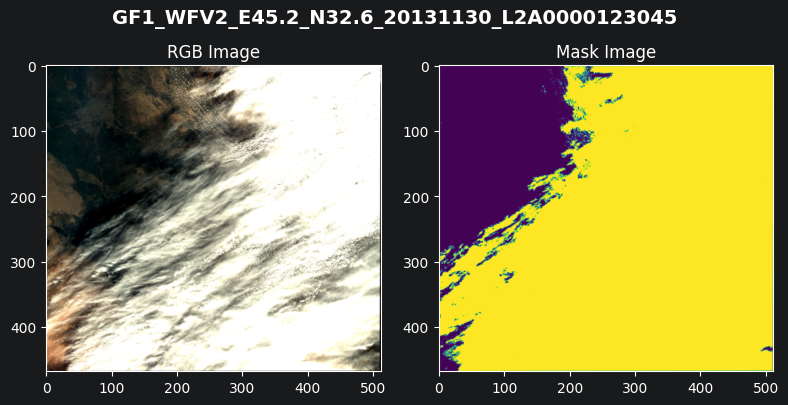

2026-05-27 10:38:06.869 | INFO     | benchmark.metadata:generate_chip_windows:255 - Generating overlapping windows: Total 1120 chips | Overlap ratio 20% | Stride 409
Processing chips: 100%|██████████| 1120/1120 [00:00<00:00, 3517.82it/s]
2026-05-27 10:38:07.208 | INFO     | benchmark.metadata:get_chips:363 - Process GF1_WFV2_E45.2_N32.6_20131130_L2A0000123045 completed! Generated 1120 valid chips.
2026-05-27 10:38:07.209 | INFO     | benchmark.metadata:predict:401 - Starting predicting chips
2026-05-27 10:38:07.209 | INFO     | benchmark.metadata:predict:405 - Loading model weights
2026-05-27 10:38:07.209 | INFO     | benchmark.metadata:load_cloud_model:99 - Loading model
2026-05-27 10:38:07.738 | INFO     | benchmark.metadata:predict:409 - Loading metadata
2026-05-27 10:38:07.738 | INFO     | benchmark.metadata:predict:413 - Found 1120 chips
2026-05-27 10:38:07.739 | INFO     | benchmark.metadata:predict:427 - Generating TTA predictions and restoring chips to a large image
predicting/

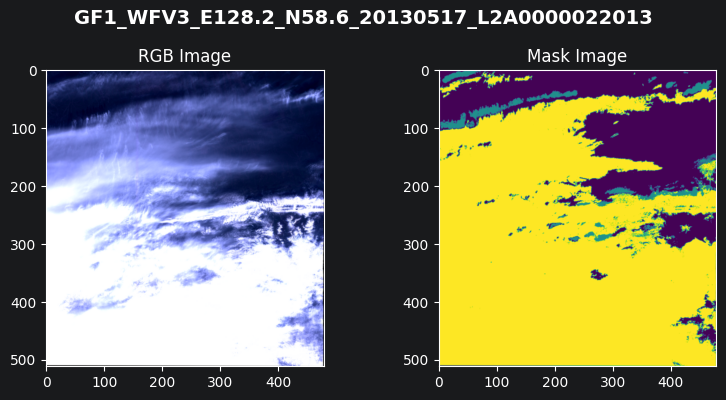

2026-05-27 10:42:34.037 | INFO     | benchmark.metadata:generate_chip_windows:255 - Generating overlapping windows: Total 960 chips | Overlap ratio 20% | Stride 409
Processing chips: 100%|██████████| 960/960 [00:08<00:00, 117.15it/s]
2026-05-27 10:42:42.252 | INFO     | benchmark.metadata:get_chips:363 - Process GF1_WFV3_E128.2_N58.6_20130517_L2A0000022013 completed! Generated 960 valid chips.
2026-05-27 10:42:42.253 | INFO     | benchmark.metadata:predict:401 - Starting predicting chips
2026-05-27 10:42:42.253 | INFO     | benchmark.metadata:predict:405 - Loading model weights
2026-05-27 10:42:42.253 | INFO     | benchmark.metadata:load_cloud_model:99 - Loading model
2026-05-27 10:42:42.792 | INFO     | benchmark.metadata:predict:409 - Loading metadata
2026-05-27 10:42:42.792 | INFO     | benchmark.metadata:predict:413 - Found 960 chips
2026-05-27 10:42:42.795 | INFO     | benchmark.metadata:predict:427 - Generating TTA predictions and restoring chips to a large image
predicting/resto

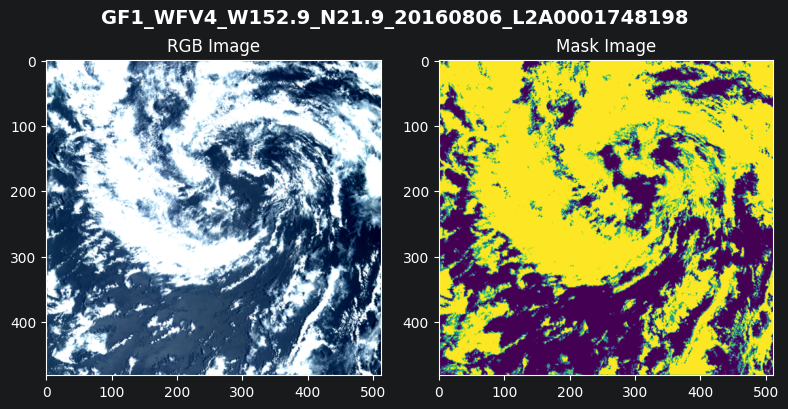

2026-05-27 10:46:37.621 | INFO     | benchmark.metadata:generate_chip_windows:255 - Generating overlapping windows: Total 1088 chips | Overlap ratio 20% | Stride 409
Processing chips: 100%|██████████| 1088/1088 [00:27<00:00, 39.85it/s]
2026-05-27 10:47:04.966 | INFO     | benchmark.metadata:get_chips:363 - Process GF1_WFV4_W152.9_N21.9_20160806_L2A0001748198 completed! Generated 1088 valid chips.
2026-05-27 10:47:04.968 | INFO     | benchmark.metadata:predict:401 - Starting predicting chips
2026-05-27 10:47:04.969 | INFO     | benchmark.metadata:predict:405 - Loading model weights
2026-05-27 10:47:04.969 | INFO     | benchmark.metadata:load_cloud_model:99 - Loading model
2026-05-27 10:47:05.678 | INFO     | benchmark.metadata:predict:409 - Loading metadata
2026-05-27 10:47:05.681 | INFO     | benchmark.metadata:predict:413 - Found 1088 chips
2026-05-27 10:47:05.683 | INFO     | benchmark.metadata:predict:427 - Generating TTA predictions and restoring chips to a large image
predicting/r

In [140]:
import traceback

try:
    if mode == "testing":
        for i in range(len(df_for_testing)):
            t = GeoTIFFTiler(df_row=df_for_testing.iloc[i], is_for_training=False, display_thumbnail=True)
            t.get_chips(CSV_OUT_DIR, IMG_OUT_DIR, LABEL_OUT_DIR)
            t.predict(PRED_OUT_DIR, fast_dev_run=False)
except Exception as e:
    traceback.print_exc()

In [141]:
from loguru import logger
from matplotlib import pyplot as plt
from pathlib import Path
import numpy as np
import rasterio
import traceback


def intersection_over_union_and_coverage(pred, true, n_classes=3):
    """
    Calculates intersection and union for a batch of images.
    Calculates coverage of each class for a batch of images.
    """
    total_pixels = true.size
    valid_pixel_mask = (true != 255)  # valid pixel mask
    true = true[valid_pixel_mask]
    pred = pred[valid_pixel_mask]

    iou_list = []
    true_coverage_list = []
    pred_coverage_list = []
    for cls in range(n_classes):
        # skip background
        if cls == 0:
            continue

        # Prediction/ground truth mask of the current category
        true_cls = (true == cls)
        pred_cls = (pred == cls)

        # Intersection and union totals
        intersection = np.logical_and(true_cls, pred_cls)
        union = np.logical_or(true_cls, pred_cls)

        iou = intersection.sum() / (union.sum() + 1e-8)
        iou_list.append(min(iou, 1))

        true_coverage = true_cls.sum() / total_pixels
        pred_coverage = pred_cls.sum() / total_pixels
        true_coverage_list.append(true_coverage)
        pred_coverage_list.append(pred_coverage)

    mIoU = np.mean(iou_list)

    return mIoU, true_coverage_list, pred_coverage_list

def display_thumbnail_more(data_path, pred_path=None, max_size=512):
    logger.info(f"Displaying thumbnail for {data_path.name}")
    with rasterio.open(data_path) as src:
        true = mask2label(src.read(5).astype(np.uint8))

        h, w = src.height, src.width
        scale = min(max_size / w, max_size / h)
        new_w, new_h = int(w * scale), int(h * scale)
        data = src.read(out_shape=(src.count, new_h, new_w),
                        resampling=rasterio.enums.Resampling.bilinear)

    b = data[0]
    g = data[1]
    r = data[2]
    nir = data[3]
    mask = data[4]
    rgb = np.dstack((r, g, b))

    rgb = stretch(rgb)

    fig, ax = plt.subplots(1, 3, figsize=(24, 8))


    ax[0].imshow(rgb)
    ax[0].set_title("RGB Image")

    ax[1].imshow(mask)
    ax[1].set_title("True Mask Image")

    if pred_path:
        with rasterio.open(pred_path) as src2:
            pred = src2.read(1).astype(np.uint8)
            pred_mask = src2.read(indexes=(1),
                                  out_shape=(src2.count, new_h, new_w),
                                  resampling=rasterio.enums.Resampling.bilinear).astype(np.uint8)

        iou, true_cov, pred_cov = intersection_over_union_and_coverage(pred, true)

        ax[1].set_title(f"True Mask Image\nshadow coverage={true_cov[0]:04f} | cloud coverage={true_cov[1]:04f} ")
        ax[2].imshow(pred_mask)
        ax[2].set_title(f"Predicted Mask Image with iou={iou:04f}\nshadow coverage={pred_cov[0]:04f} | cloud coverage={pred_cov[1]:04f}")

    plt.tight_layout()
    plt.show()

In [142]:
data_dir = DATA_DIR / "GF1_B02_B03_B04_B08_Mask"
data_tif_files = list(data_dir.glob("*.tif"))
data_tif_files[0].stem

'GF1_WFV4_W155.2_N20.2_20160721_L2A0001718813'

In [143]:
pred_dir = DATA_DIR / "predictions"
pred_tif_files = list(pred_dir.glob("*_PredictedMask.tif"))
pred_tif_files

[PosixPath('/Users/hangzegao/PycharmProjects/cloud/data/predictions/GF1_WFV3_E128.2_N58.6_20130517_L2A0000022013_PredictedMask.tif'),
 PosixPath('/Users/hangzegao/PycharmProjects/cloud/data/predictions/GF1_WFV4_W152.9_N21.9_20160806_L2A0001748198_PredictedMask.tif'),
 PosixPath('/Users/hangzegao/PycharmProjects/cloud/data/predictions/GF1_WFV4_W155.2_N20.2_20160721_L2A0001718813_PredictedMask.tif'),
 PosixPath('/Users/hangzegao/PycharmProjects/cloud/data/predictions/GF1_WFV2_E45.2_N32.6_20131130_L2A0000123045_PredictedMask.tif'),
 PosixPath('/Users/hangzegao/PycharmProjects/cloud/data/predictions/GF1_WFV1_E88.6_N28.0_20141208_L2A0000845193_PredictedMask.tif')]

2026-05-27 10:51:20.014 | INFO     | __main__:display_thumbnail_more:48 - Displaying thumbnail for GF1_WFV4_W155.2_N20.2_20160721_L2A0001718813.tif


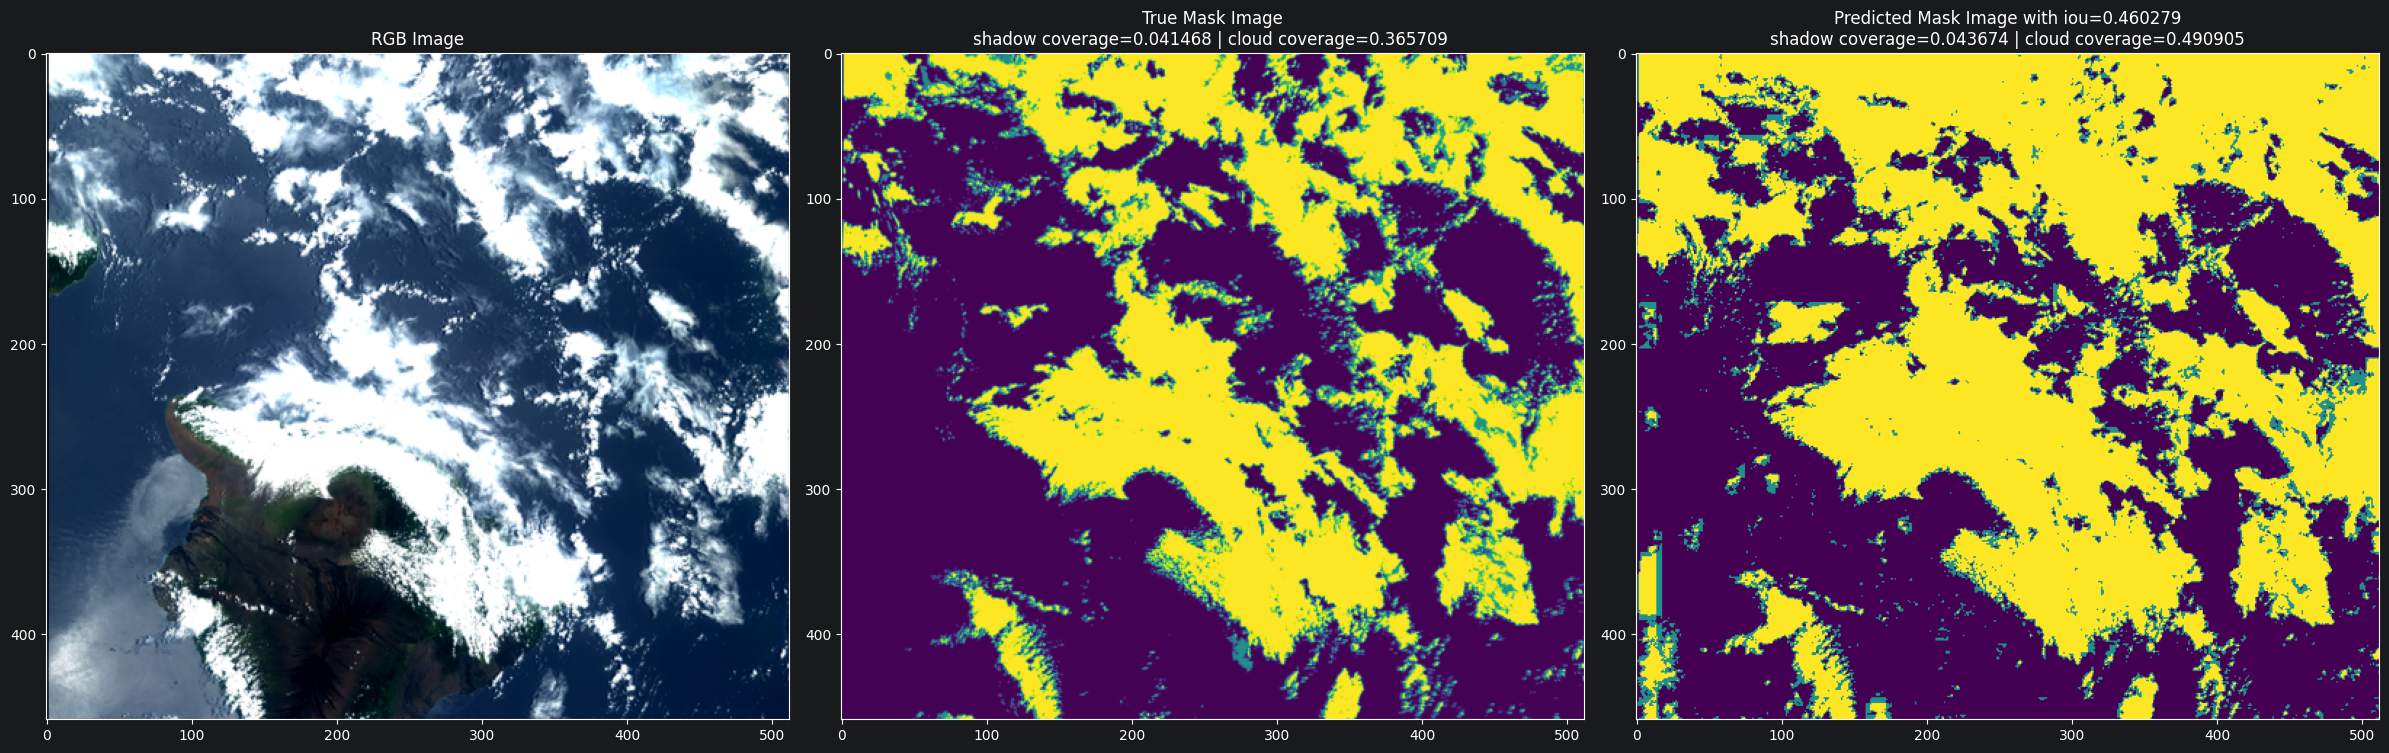

2026-05-27 10:51:34.776 | INFO     | __main__:display_thumbnail_more:48 - Displaying thumbnail for GF1_WFV4_W152.9_N21.9_20160806_L2A0001748198.tif


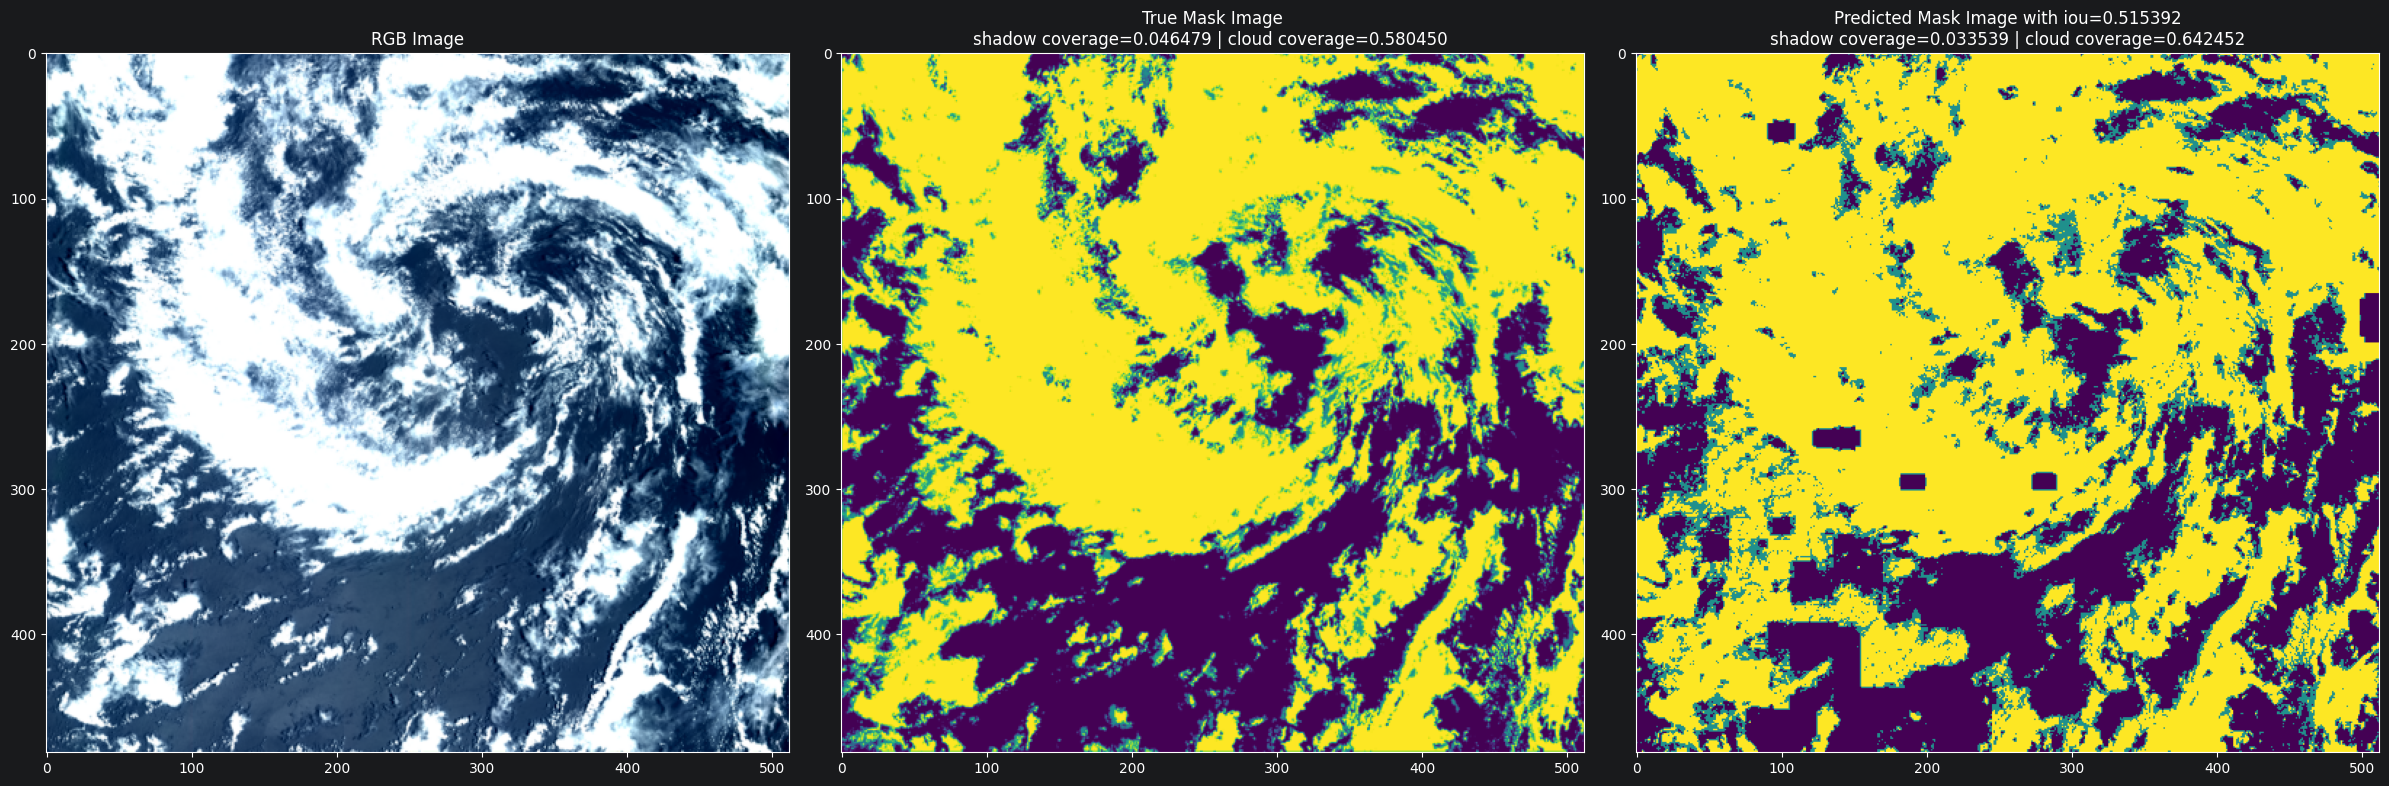

2026-05-27 10:51:47.945 | INFO     | __main__:display_thumbnail_more:48 - Displaying thumbnail for GF1_WFV3_E128.2_N58.6_20130517_L2A0000022013.tif


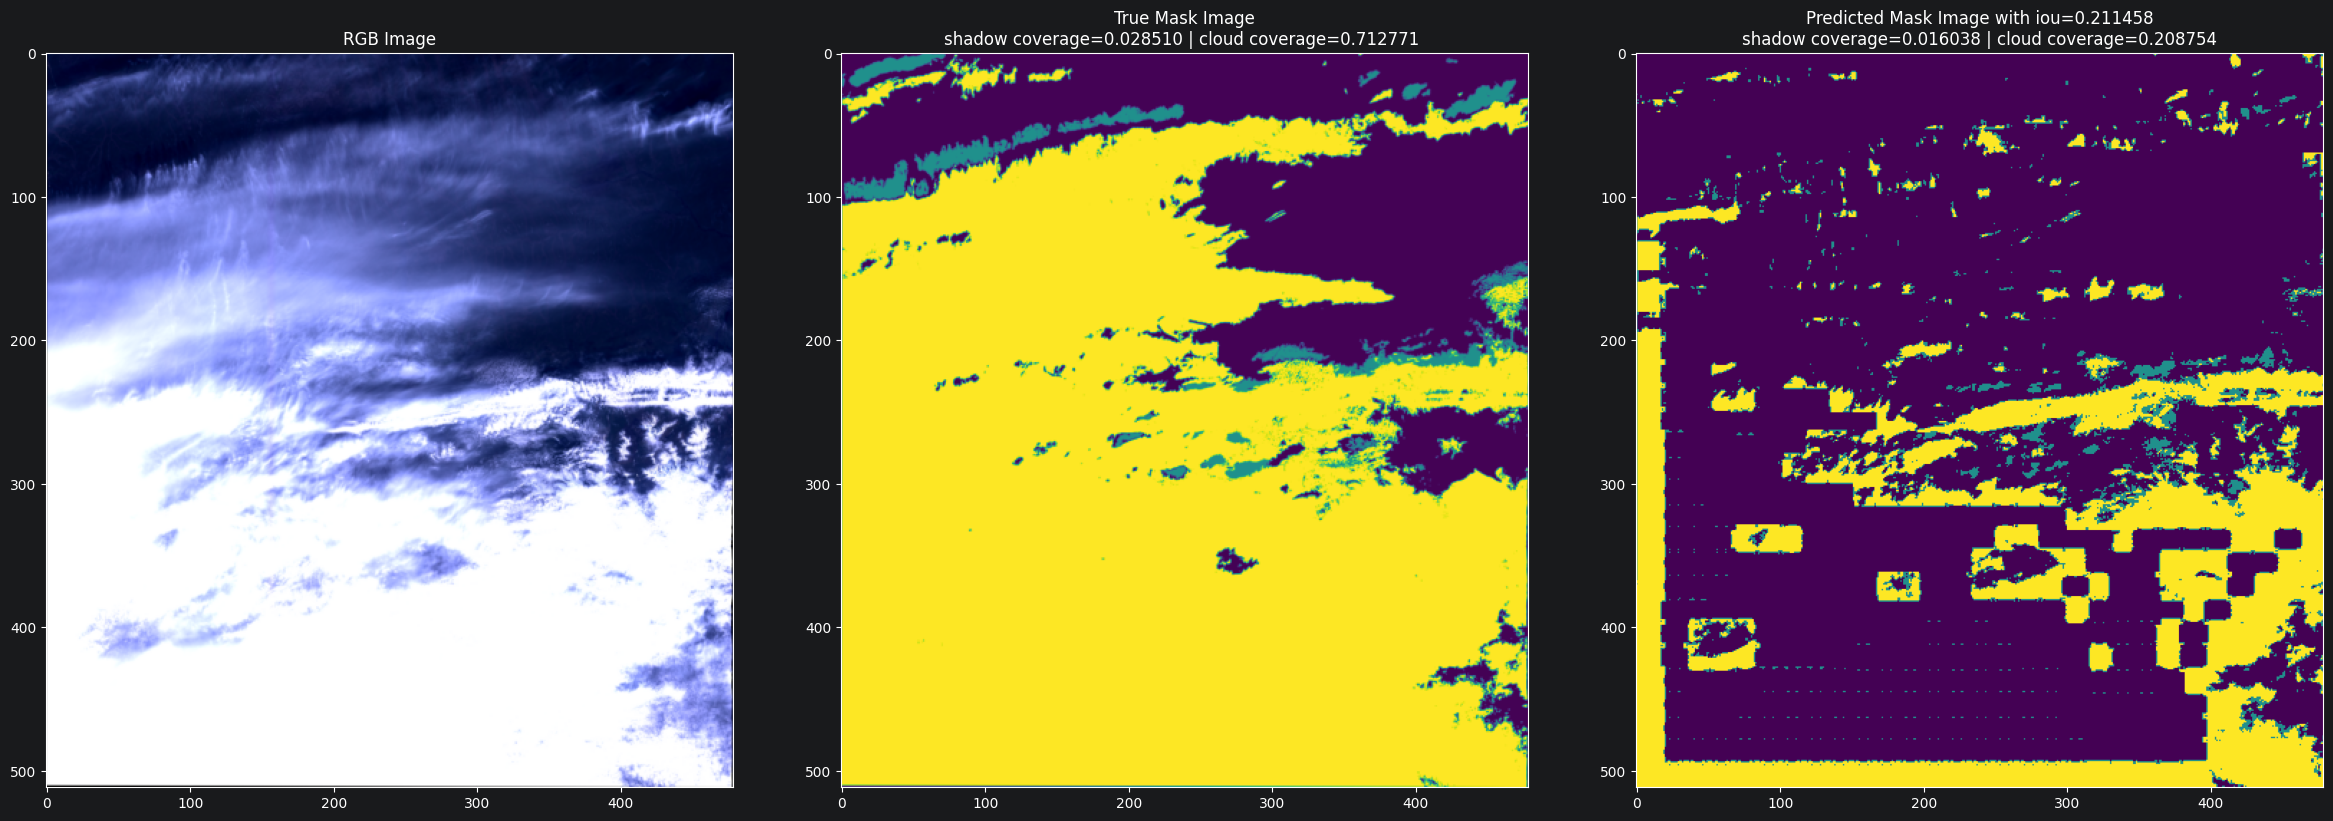

2026-05-27 10:51:57.643 | INFO     | __main__:display_thumbnail_more:48 - Displaying thumbnail for GF1_WFV2_E45.2_N32.6_20131130_L2A0000123045.tif


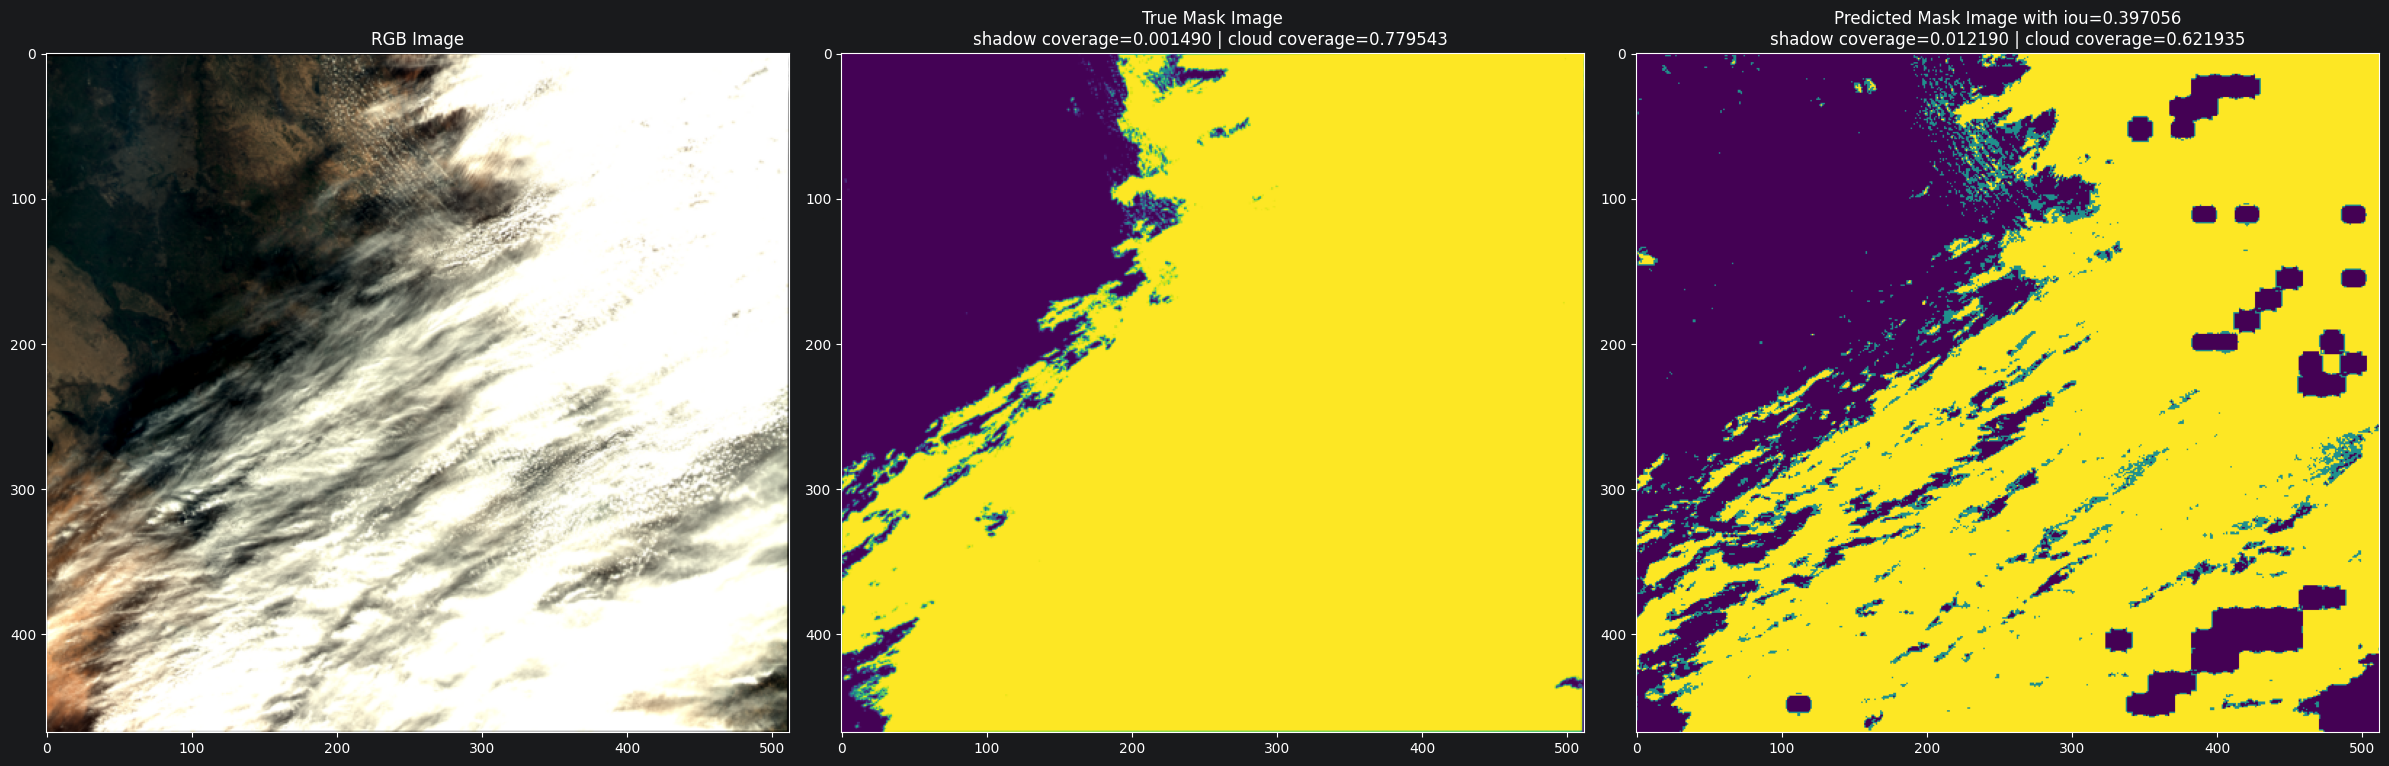

In [144]:
try:
    for data_tif_file in data_tif_files:
        for pred_tif_file in pred_tif_files:
            filename = str(data_tif_file.stem)
            if filename in str(pred_tif_file):
                display_thumbnail_more(data_tif_file, pred_tif_file)
except Exception as e:
    traceback.print_exc()